In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Kaggle dataset directory
# Make sure the dataset 'puneet6060/intel-image-classification' is added under "Add Input" on Kaggle.
BASE_DIR = '/kaggle/input/datasets/puneet6060/intel-image-classification'
data_dir = os.path.join(BASE_DIR, 'seg_train', 'seg_train')
classes = os.listdir(data_dir)
classes

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']

In [3]:
print(data_dir)
print(os.listdir(data_dir))

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


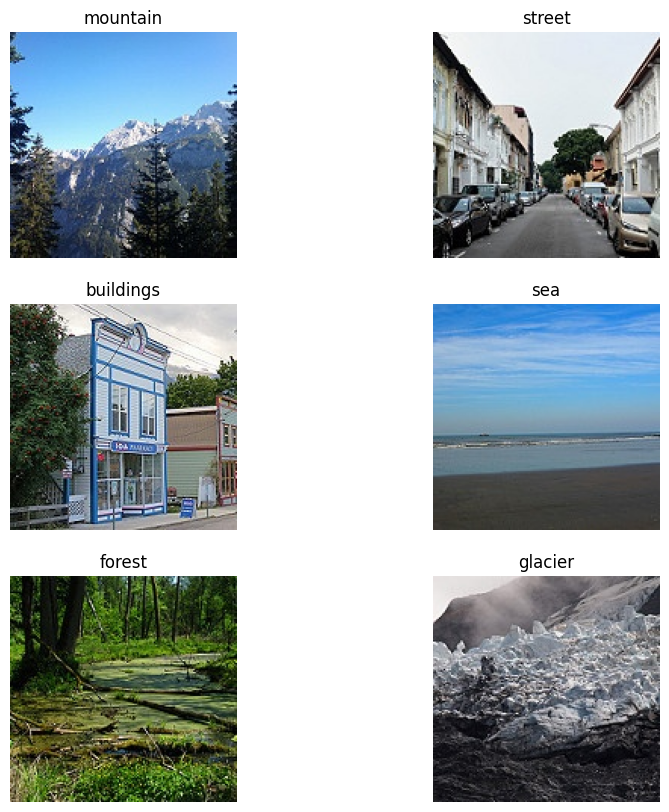

In [4]:
import random

plt.figure(figsize=(10,10))
for i, cls in enumerate(classes):
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.show()


In [5]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray


In [6]:
orb = cv2.ORB_create(nfeatures=500)

#### ORB = Oriented FAST + Rotated BRIEF

#### nfeatures=500 → max 500 keypoints per image

In [7]:
# ORB function

def extract_orb_features(image):
    keypoints, descriptors = orb.detectAndCompute(image, None)
    if descriptors is None:
        return np.zeros(500)
    descriptors = descriptors.flatten()
    if len(descriptors) < 500:
        descriptors = np.pad(descriptors, (0, 500-len(descriptors)))
    return descriptors[:500]


In [8]:
# make feature matrix from dataset

X = []
y = []

for label, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    for img_name in os.listdir(cls_path)[:300]:
        img_path = os.path.join(cls_path, img_name)
        img = preprocess_image(img_path)
        features = extract_orb_features(img)
        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)


In [9]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X, y)


SVC(kernel='linear')

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X, y)


RandomForestClassifier()

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)


KNeighborsClassifier()

Accuracy: 0.9983333333333333


<Axes: >

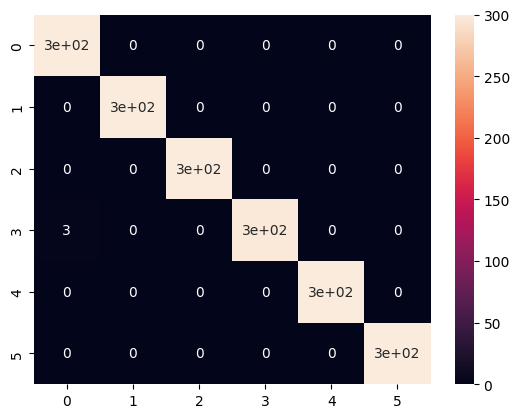

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

y_pred = svm.predict(X)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True)


Accuracy: 0.9983333333333333


<Axes: >

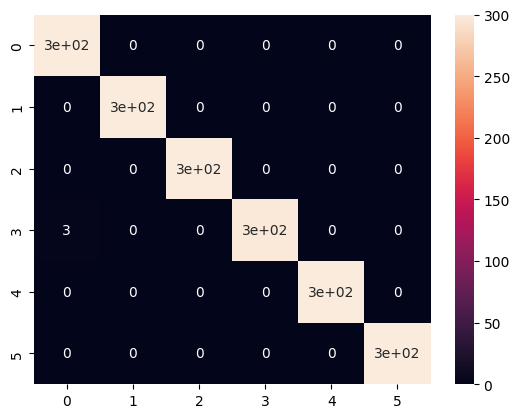

In [13]:
y_pred1 = rf.predict(X)
acc1 = accuracy_score(y, y_pred1)
print("Accuracy:", acc1)

cm = confusion_matrix(y, y_pred1)
sns.heatmap(cm, annot=True)


Accuracy: 0.4533333333333333


<Axes: >

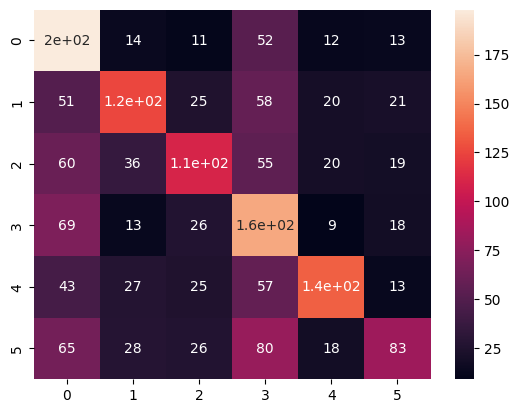

In [14]:
y_pred2 = knn.predict(X)
acc2 = accuracy_score(y, y_pred2)
print("Accuracy:", acc2)

cm = confusion_matrix(y, y_pred2)
sns.heatmap(cm, annot=True)


### Model Comparison (Visualized)

           Model  Accuracy
0            SVM  0.998333
1  Random Forest  0.998333
2            kNN  0.453333


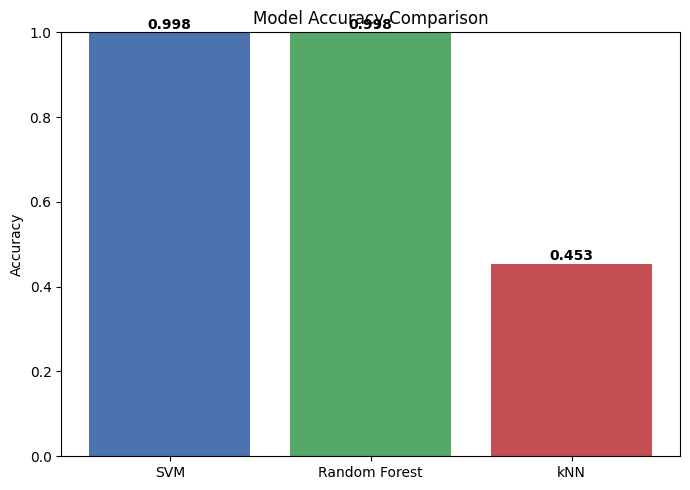

Best model: SVM with accuracy 0.9983


In [15]:
import pandas as pd

model_names = ['SVM', 'Random Forest', 'kNN']
accuracies = [acc, acc1, acc2]

comparison_df = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(comparison_df)

plt.figure(figsize=(7,5))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for bar, acc_val in zip(bars, comparison_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc_val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]['Model']
print(f'Best model: {best_model_name} with accuracy {comparison_df.iloc[0]["Accuracy"]:.4f}')

In [16]:
import joblib
joblib.dump(svm, 'best_model.pkl')

['best_model.pkl']

In [17]:
import joblib
joblib.dump(svm, "best_model.pkl")

['best_model.pkl']

In [ ]:
# the streamlit app code is present in local pc folder

### Download Saved Model Weight